<a href="https://colab.research.google.com/github/gopalkrishnaattem580-coder/Information-System-Lab/blob/main/dam_model_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Processing measuring point: J23

[1] Stepwise Regression:
  Train: RMSE=1.1123, R²=0.8829, MCC=0.9396, RSD=1.1123
  Test: RMSE=3.2905, R²=-0.1187, MCC=0.0000, RSD=1.2833

[2] Partial Least Squares:
  Train: RMSE=1.1882, R²=0.8663, MCC=0.9308, RSD=1.1882
  Test: RMSE=2.5486, R²=0.3289, MCC=0.5735, RSD=1.2246

[3] PINN (Physics-Informed Neural Network):
Training PINN: 3000 epochs, lambda_phys=0.5
  Epoch  200: loss=0.33734 (data=0.15176, phys=0.29634)
  Epoch  400: loss=0.25550 (data=0.11833, phys=0.21763)
  Epoch  600: loss=0.19960 (data=0.09360, phys=0.16803)
  Epoch  800: loss=0.15993 (data=0.07629, phys=0.13220)
  Epoch 1000: loss=0.13144 (data=0.05954, phys=0.11506)
  Epoch 1200: loss=0.11190 (data=0.05383, phys=0.09186)
  Epoch 1400: loss=0.09739 (data=0.04510, phys=0.08348)
  Epoch 1600: loss=0.08695 (data=0.04105, phys=0.07296)
  Epoch 1800: loss=0.07998 (data=0.03918, phys=0.06437)
  Epoch 2000: loss=0.07491 (data=0.03533, phys=0.06307)
  Epoch 2200: loss=0.07130 (data=0.03356,

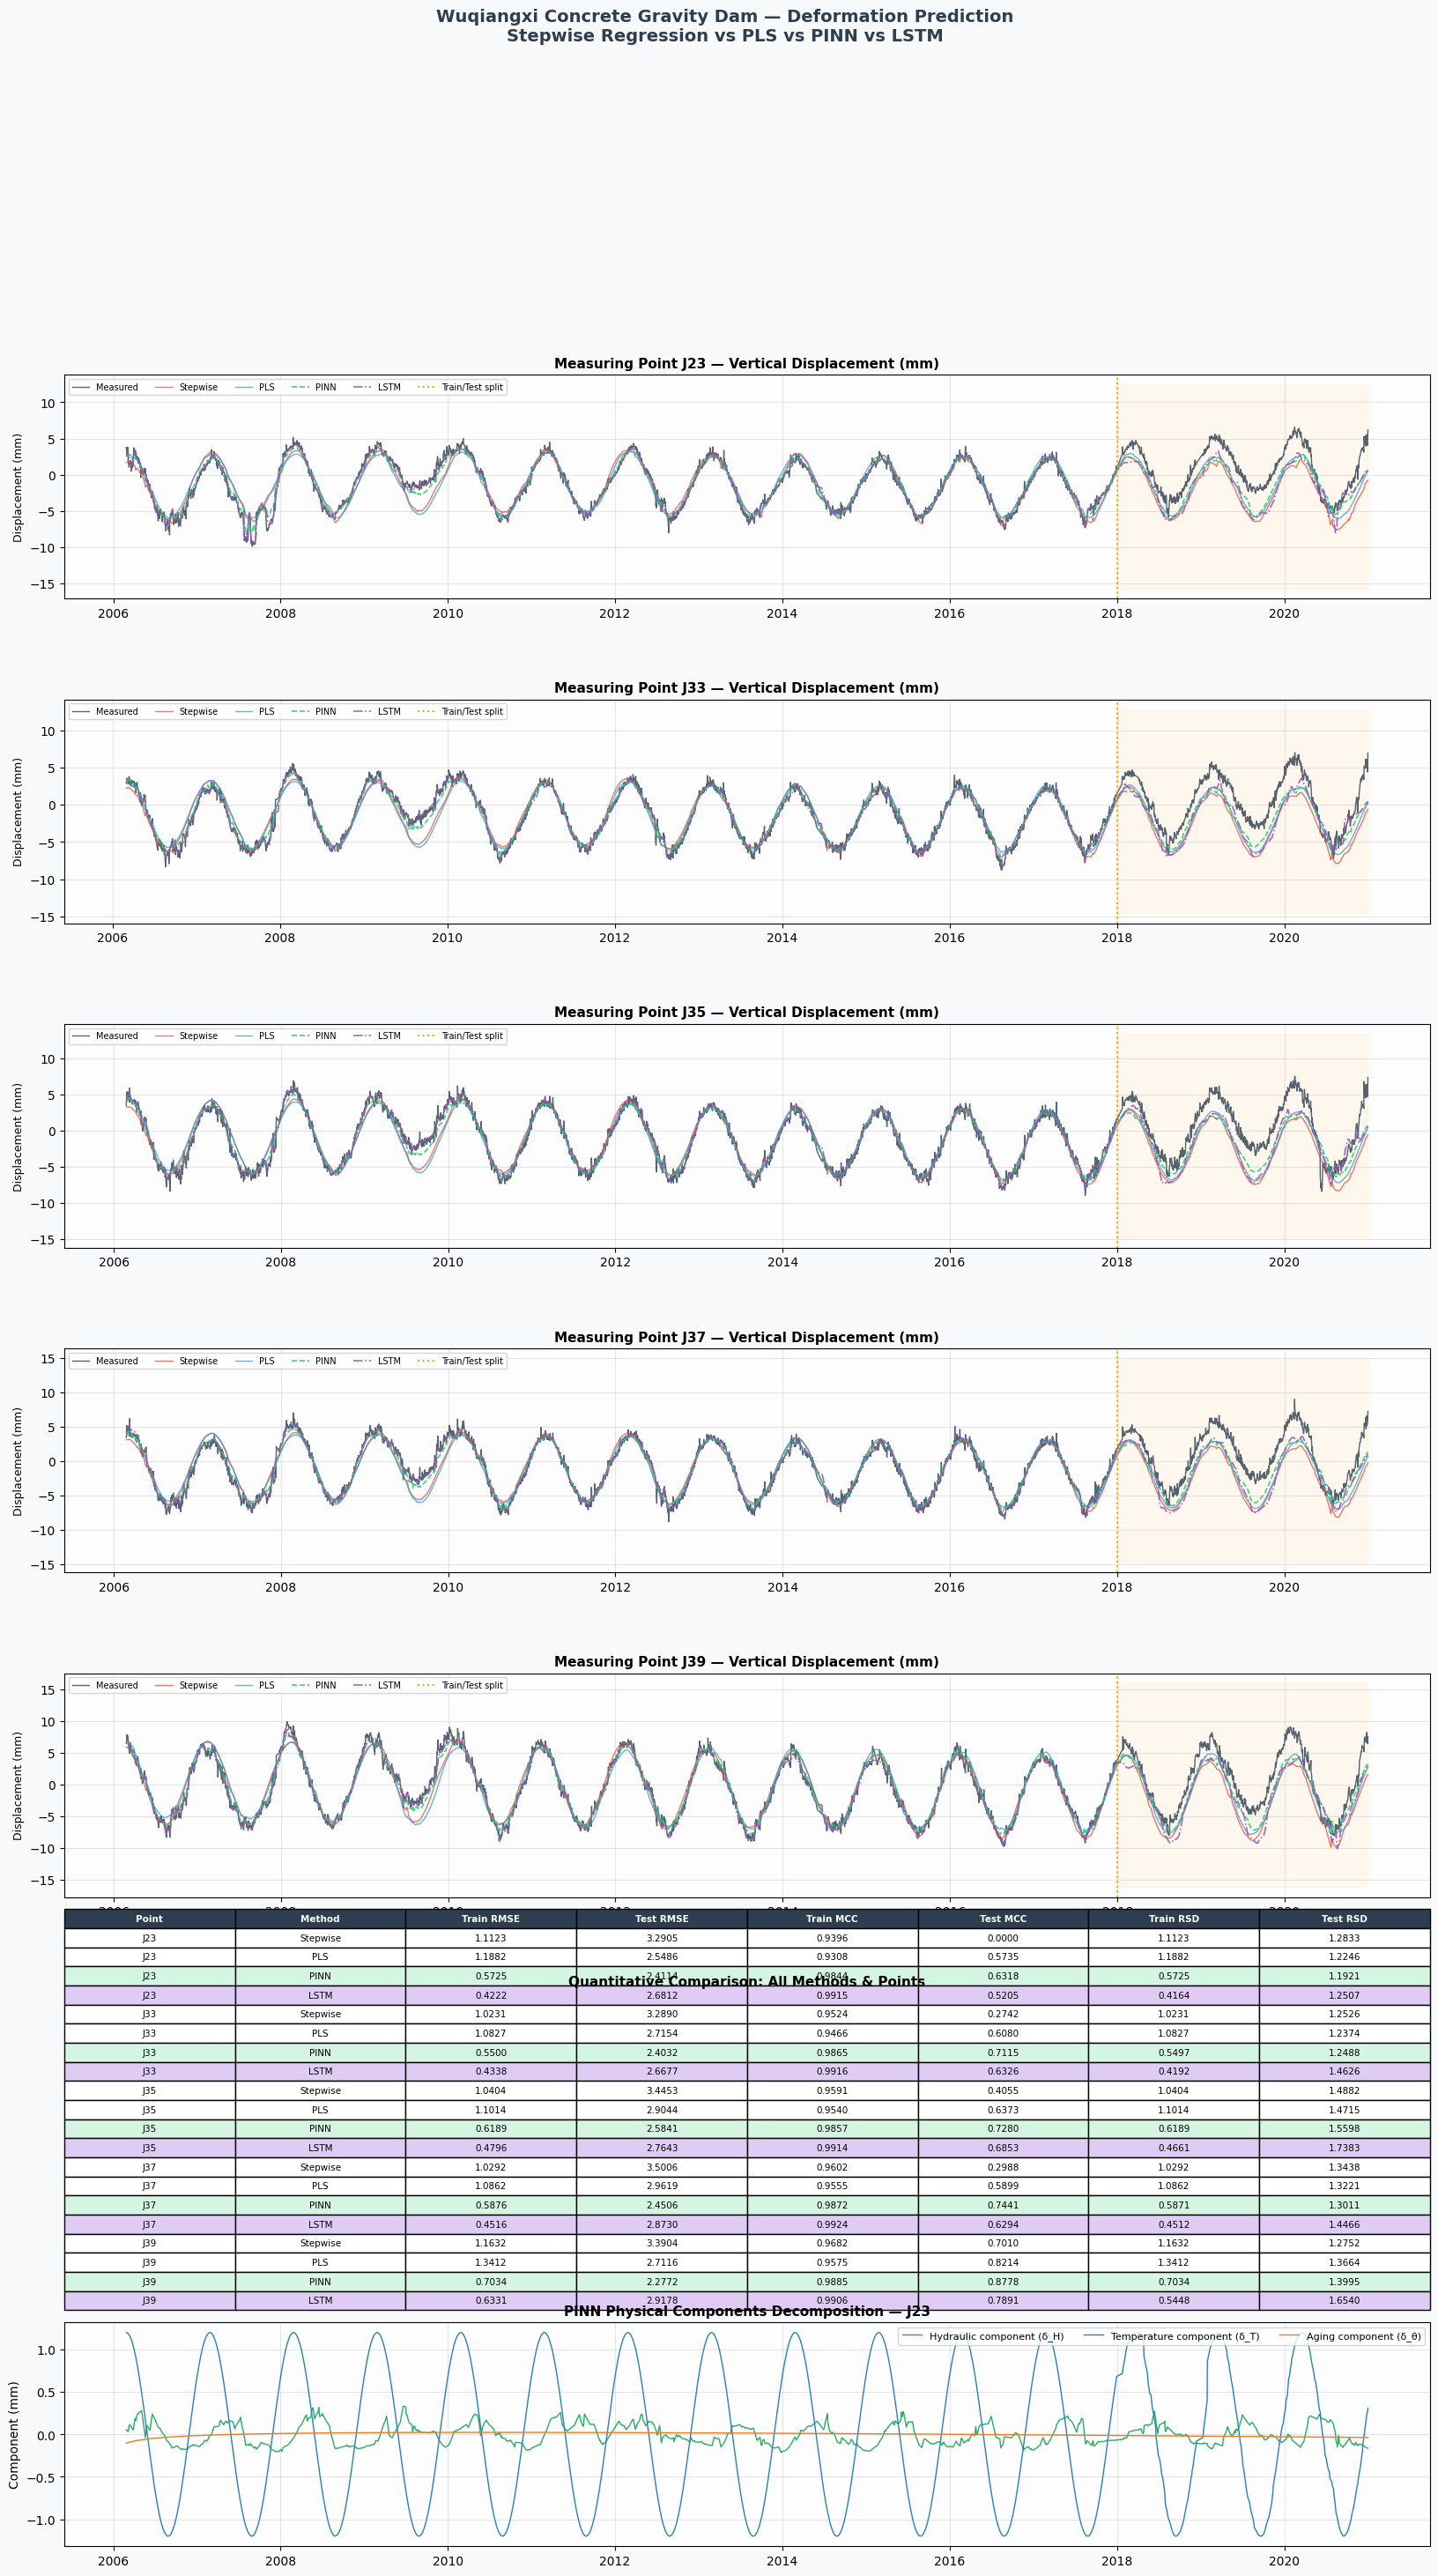

In [7]:

"""
PINN (Physics-Informed Neural Network) for Wuqiangxi Dam Deformation Prediction
Based on: Yang et al. (2022) - CMES paper
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from datetime import datetime, timedelta
import struct
import warnings
warnings.filterwarnings('ignore')

# Import for LSTM
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

# ============================================================
# SECTION 1: DATA LOADING (custom .xls parser - no xlrd needed)
# ============================================================

EXCEL_EPOCH = datetime(1899, 12, 30)

def read_ole_stream(filename):
    """Read OLE2 compound document and extract Workbook stream"""
    with open(filename, 'rb') as f: data = f.read()
    ss = 2 ** struct.unpack_from('<H', data, 30)[0]
    nf = struct.unpack_from('<I', data, 44)[0]
    fat_secs = [struct.unpack_from('<I',data,76+i*4)[0] for i in range(min(nf,109))
                if struct.unpack_from('<I',data,76+i*4)[0] < 0xFFFFFFFC]
    fat = []
    for s in fat_secs:
        for i in range(ss//4): fat.append(struct.unpack_from('<I',data,(s+1)*ss+i*4)[0])
    def chain(start, size=None):
        r,s,v = b'',start,set()
        while s<0xFFFFFFFE and s not in v and s<len(fat):
            v.add(s); r+=data[(s+1)*ss:(s+2)*ss]; s=fat[s]
        return r[:size] if size else r
    dd = chain(struct.unpack_from('<I',data,48)[0])
    for i in range(len(dd)//128):
        e=dd[i*128:(i+1)*128]; nl=struct.unpack_from('<H',e,64)[0]
        if nl>0:
            nm=e[:nl-2].decode('utf-16-le','ignore').lower()
            if nm in ('workbook','book') and e[66]==2:
                return chain(struct.unpack_from('<I',e,116)[0], struct.unpack_from('<I',e,120)[0])

def decode_rk(rk):
    fX100=bool(rk&1); fInt=bool(rk&2)
    if fInt:
        val=float(rk>>2)
        if rk&0x80000000: val=float((rk>>2)|0xC0000000)-(1<<32)+(1<<2)
    else:
        b=struct.pack('>I',rk&0xFFFFFFFC)+b'\x00\x00\x00\x00'
        val=struct.unpack('>d',b)[0]
    if fX100: val/=100
    return val

def parse_sheet(wb):
    pos=0; sst=[]; xf_list=[]; cells={}
    while pos<len(wb)-4:
        rt=struct.unpack_from('<H',wb,pos)[0]
        rl=struct.unpack_from('<H',wb,pos+2)[0]
        rd=wb[pos+4:pos+4+rl]
        if rt==0x00E0 and len(rd)>=4: xf_list.append(struct.unpack_from('<H',rd,2)[0])
        elif rt==0x00FC and len(rd)>=8:
            n=struct.unpack_from('<I',rd,4)[0]; sp=8
            for _ in range(n):
                if sp+3>len(rd): break
                cc=struct.unpack_from('<H',rd,sp)[0]; fl=rd[sp+2]; sp+=3
                if fl&4: sp+=2+struct.unpack_from('<H',rd,sp)[0]*4
                if fl&8: sp+=4+struct.unpack_from('<I',rd,sp)[0]
                if fl&1: s=rd[sp:sp+cc*2].decode('utf-16-le','ignore'); sp+=cc*2
                else: s=rd[sp:sp+cc].decode('latin-1','ignore'); sp+=cc
                sst.append(s)
        elif rt==0x00BD and len(rd)>=6:
            row=struct.unpack_from('<H',rd,0)[0]; cf=struct.unpack_from('<H',rd,2)[0]
            for i in range((rl-6)//6):
                xf=struct.unpack_from('<H',rd,4+i*6)[0]; rk=struct.unpack_from('<I',rd,4+i*6+2)[0]
                val=decode_rk(rk); fi=xf_list[xf] if xf<len(xf_list) else 0
                if 14<=fi<=22 or 45<=fi<=47: val=EXCEL_EPOCH+timedelta(days=val)
                cells[(row,cf+i)]=val
        elif rt==0x0203 and len(rd)>=14:
            row=struct.unpack_from('<H',rd,0)[0]; col=struct.unpack_from('<H',rd,2)[0]
            xf=struct.unpack_from('<H',rd,4)[0]; val=struct.unpack_from('<d',rd,6)[0]
            fi=xf_list[xf] if xf<len(xf_list) else 0
            if 14<=fi<=22 or 45<=fi<=47: val=EXCEL_EPOCH+timedelta(days=val)
            cells[(row,col)]=val
        elif rt==0x00FD and len(rd)>=8:
            row=struct.unpack_from('<H',rd,0)[0]; col=struct.unpack_from('<H',rd,2)[0]
            si=struct.unpack_from('<I',rd,6)[0]
            if si<len(sst): cells[(row,col)]=sst[si]
        pos+=4+rl
    if not cells: return pd.DataFrame()
    mr=max(r for r,c in cells)+1; mc=max(c for r,c in cells)+1
    arr=[[cells.get((r,c),np.nan) for c in range(mc)] for r in range(mr)]
    df=pd.DataFrame(arr)
    h0=df.iloc[0]
    if any(isinstance(v,str) and len(str(v))>0 for v in h0):
        df.columns=[str(v) if isinstance(v,str) else f'col{i}' for i,v in enumerate(h0)]
        df=df.iloc[1:].reset_index(drop=True)
    return df

def load_xls(path):
    wb = read_ole_stream(path)
    df = parse_sheet(wb)
    df.columns = ['date','value']
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df = df.dropna(subset=['date']).sort_values('date').reset_index(drop=True)
    return df

# Load all data
BASE = "/content/drive/MyDrive/dam_DATA/"  # change this to your path
data = {
    'J23': load_xls(BASE+'J23.xls'),
    'J33': load_xls(BASE+'J33.xls'),
    'J35': load_xls(BASE+'J35.xls'),
    'J37': load_xls(BASE+'J37.xls'),
    'J39': load_xls(BASE+'J39.xls'),
    'temp': load_xls(BASE+'temperature.xls'),
    'H':    load_xls(BASE+'water_level_upstream.xls'),
    'h':    load_xls(BASE+'water_level_downstream.xls'),
}

# ============================================================
# SECTION 2: FEATURE ENGINEERING
# ============================================================

def build_dataset(disp_df, temp_df, H_df, h_df):
    """Merge all inputs and build feature matrix following Eq.(8) of the paper"""
    # Common date reference
    ref_date = disp_df['date'].min()

    # Interpolate water levels (sparse) to daily
    all_dates = pd.date_range(disp_df['date'].min(), disp_df['date'].max(), freq='D')

    H_interp = pd.Series(H_df['value'].values, index=H_df['date']).reindex(all_dates).interpolate('linear')
    h_interp = pd.Series(h_df['value'].values, index=h_df['date']).reindex(all_dates).interpolate('linear').bfill()
    T_interp = pd.Series(temp_df['value'].values, index=temp_df['date']).reindex(all_dates).interpolate('linear')
    Y_interp = pd.Series(disp_df['value'].values, index=disp_df['date']).reindex(all_dates)

    df = pd.DataFrame({
        'date': all_dates,
        'H': H_interp.values,
        'h': h_interp.values,
        'T': T_interp.values,
        'y': Y_interp.values
    }).dropna()

    # Days since start
    df['t'] = (df['date'] - ref_date).dt.days.values.astype(float)
    # Cumulative days from dam construction reference (Jan 1, 2006)
    t_ref = datetime(2006, 1, 1)
    df['t_abs'] = (df['date'] - t_ref).dt.days.values.astype(float)

    # Hydraulic features (Eq. 5)
    for i in range(1, 4):
        df[f'H{i}'] = df['H'] ** i
        df[f'h{i}'] = df['h'] ** i

    # Temperature features (Eq. 6)
    df['sin_t'] = np.sin(2 * np.pi * df['t_abs'] / 365)
    df['cos_t'] = np.cos(2 * np.pi * df['t_abs'] / 365)

    # Aging features (Eq. 7) — theta = t/100
    df['theta'] = df['t_abs'] / 100
    df['theta_lin'] = df['theta']
    df['theta_log'] = np.log(df['theta'] + 1e-6)

    return df.reset_index(drop=True)

# ============================================================
# SECTION 3: STEPWISE REGRESSION (Paper method 1)
# ============================================================
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

def stepwise_regression(X, y, feature_names, threshold_in=0.05):
    """F-test based stepwise regression"""
    from scipy import stats
    included = []
    while True:
        changed = False
        excluded = [f for f in feature_names if f not in included]
        best_pval = threshold_in
        best_feat = None
        for feat in excluded:
            test = included + [feat]
            model = LinearRegression().fit(X[test].values, y)
            y_pred = model.predict(X[test].values)
            n, k = len(y), len(test)
            sse = np.sum((y - y_pred)**2)
            sst = np.sum((y - y.mean())**2)
            mse = sse / max(n - k - 1, 1)
            # F-test for new variable
            if len(included) > 0:
                model0 = LinearRegression().fit(X[included].values, y)
                sse0 = np.sum((y - model0.predict(X[included].values))**2)
                F = (sse0 - sse) / mse
            else:
                F = (sst - sse) / mse
            pval = 1 - stats.f.cdf(F, 1, max(n-k-1,1))
            if pval < best_pval:
                best_pval, best_feat = pval, feat
        if best_feat:
            included.append(best_feat)
            changed = True
        if not changed: break
    model = LinearRegression().fit(X[included].values, y)
    return model, included

# ============================================================
# SECTION 4: PARTIAL LEAST SQUARES (Paper method 2)
# ============================================================
from sklearn.cross_decomposition import PLSRegression

def fit_pls(X_train, y_train, X_test, n_components=3):
    pls = PLSRegression(n_components=n_components, max_iter=1000)
    pls.fit(X_train, y_train)
    return pls, pls.predict(X_train).ravel(), pls.predict(X_test).ravel()

# ============================================================
# SECTION 5: PINN (Physics-Informed Neural Network)
# Pure NumPy implementation — no PyTorch/TF required
# ============================================================

class PINN:
    """
    Physics-Informed Neural Network for dam deformation prediction.

    Architecture: Fully connected network with tanh activations.
    Physics constraint: Displacement = Hydraulic + Temperature + Aging components

    Loss = L_data + lambda * L_physics

    Physical equations embedded as soft constraints:
    - delta_H = sum(a1i*H^i + a2i*h^i) for i=1,2,3  [Eq. 5]
    - delta_T = b1*sin(2pi*t/365) + b2*cos(2pi*t/365)  [Eq. 6]
    - delta_theta = c1*theta + c2*ln(theta)  [Eq. 7]
    - delta = delta_H + delta_T + delta_theta  [Eq. 8]
    """

    def __init__(self, input_dim, hidden_dims=[64, 64, 32], lr=0.001, lambda_phys=0.1, epochs=2000):
        self.input_dim = input_dim
        self.hidden_dims = hidden_dims
        self.lr = lr
        self.lambda_phys = lambda_phys
        self.epochs = epochs
        self.loss_history = []
        self._init_weights()

    def _init_weights(self):
        dims = [self.input_dim] + self.hidden_dims + [1]
        self.W = []
        self.b = []
        for i in range(len(dims)-1):
            # Xavier initialization
            scale = np.sqrt(2.0 / (dims[i] + dims[i+1]))
            self.W.append(np.random.randn(dims[i], dims[i+1]) * scale)
            self.b.append(np.zeros(dims[i+1]))
        # Physics branch weights (linear layer for each component)
        # Hydraulic: 6 inputs (H1,H2,H3,h1,h2,h3) -> 1 output
        self.W_H = np.random.randn(6, 1) * 0.01
        # Temperature: 2 inputs (sin_t, cos_t) -> 1 output
        self.W_T = np.random.randn(2, 1) * 0.01
        # Aging: 2 inputs (theta, log_theta) -> 1 output
        self.W_A = np.random.randn(2, 1) * 0.01
        # Adam optimizer states
        self.m_W = [np.zeros_like(w) for w in self.W]
        self.v_W = [np.zeros_like(w) for w in self.W]
        self.m_b = [np.zeros_like(b) for b in self.b]
        self.v_b = [np.zeros_like(b) for b in self.b]

    def _tanh(self, x): return np.tanh(x)
    def _tanh_grad(self, x): return 1 - np.tanh(x)**2

    def forward(self, X):
        """Forward pass through main network"""
        self.activations = [X]
        self.preactivations = []
        a = X
        for i, (W, b) in enumerate(zip(self.W, self.b)):
            z = a @ W + b
            self.preactivations.append(z)
            if i < len(self.W) - 1:
                a = self._tanh(z)
            else:
                a = z  # linear output layer
            self.activations.append(a)
        return a

    def physics_predict(self, X_H, X_T, X_A):
        """Predict each physical component using linear physics layers"""
        delta_H = X_H @ self.W_H
        delta_T = X_T @ self.W_T
        delta_A = X_A @ self.W_A
        return delta_H, delta_T, delta_A

    def compute_loss(self, X, y, X_H, X_T, X_A):
        """Compute total loss = data loss + physics-informed loss"""
        # Main network prediction
        y_pred = self.forward(X)
        y = y.reshape(-1, 1)

        # Data loss (MSE)
        L_data = np.mean((y_pred - y)**2)

        # Physics prediction
        dH, dT, dA = self.physics_predict(X_H, X_T, X_A)
        y_phys = dH + dT + dA

        # Physics loss: network output should match sum of physical components
        L_phys = np.mean((y_pred - y_phys)**2)

        # Component regularization: physics should predict well
        L_comp = np.mean((y_phys - y)**2)

        total = L_data + self.lambda_phys * (L_phys + 0.1 * L_comp)
        return total, L_data, L_phys, y_pred.ravel()

    def backward(self, X, y, X_H, X_T, X_A):
        """Backpropagation"""
        n = len(y)
        y = y.reshape(-1, 1)
        y_pred = self.activations[-1]

        # Physics terms
        dH = X_H @ self.W_H
        dT = X_T @ self.W_T
        dA = X_A @ self.W_A
        y_phys = dH + dT + dA

        # Gradient of data loss
        dL_data = 2 * (y_pred - y) / n

        # Gradient of physics loss (y_pred - y_phys)
        dL_phys = 2 * self.lambda_phys * (y_pred - y_phys) / n

        # Total gradient at output
        delta = dL_data + dL_phys

        # Backprop through main network
        grads_W = [None] * len(self.W)
        grads_b = [None] * len(self.b)

        for i in range(len(self.W)-1, -1, -1):
            grads_W[i] = self.activations[i].T @ delta
            grads_b[i] = delta.sum(axis=0)
            if i > 0:
                delta = (delta @ self.W[i].T) * self._tanh_grad(self.preactivations[i-1])

        # Gradients for physics branch weights
        # d(L_phys)/d(W_H): d/dW_H of |y_pred - X_H*W_H - X_T*W_T - X_A*W_A|^2
        phys_resid = y_phys - y_pred  # gradient goes the other way for physics params
        dL_phys_comp = 2 * self.lambda_phys * phys_resid / n
        dL_comp = 0.2 * self.lambda_phys * 2 * (y_phys - y) / n

        grad_phys = dL_phys_comp + dL_comp
        grad_W_H = X_H.T @ grad_phys
        grad_W_T = X_T.T @ grad_phys
        grad_W_A = X_A.T @ grad_phys

        return grads_W, grads_b, grad_W_H, grad_W_T, grad_W_A

    def adam_update(self, grads_W, grads_b, gWH, gWT, gWA, t):
        """Adam optimizer update"""
        beta1, beta2, eps = 0.9, 0.999, 1e-8
        for i in range(len(self.W)):
            self.m_W[i] = beta1*self.m_W[i] + (1-beta1)*grads_W[i]
            self.v_W[i] = beta2*self.v_W[i] + (1-beta2)*grads_W[i]**2
            mh = self.m_W[i]/(1-beta1**t)
            vh = self.v_W[i]/(1-beta2**t)
            self.W[i] -= self.lr * mh / (np.sqrt(vh) + eps)

            self.m_b[i] = beta1*self.m_b[i] + (1-beta1)*grads_b[i]
            self.v_b[i] = beta2*self.v_b[i] + (1-beta2)*grads_b[i]**2
            mh = self.m_b[i]/(1-beta1**t)
            vh = self.v_b[i]/(1-beta2**t)
            self.b[i] -= self.lr * mh / (np.sqrt(vh) + eps)

        # Update physics weights (simple SGD for stability)
        self.W_H -= self.lr * gWH
        self.W_T -= self.lr * gWT
        self.W_A -= self.lr * gWA

    def fit(self, X, y, X_H, X_T, X_A, X_val=None, y_val=None, X_H_v=None, X_T_v=None, X_A_v=None):
        """Train PINN"""
        print(f"Training PINN: {self.epochs} epochs, lambda_phys={self.lambda_phys}")
        # Normalize inputs
        self.X_mean = X.mean(0); self.X_std = X.std(0) + 1e-8
        self.y_mean = y.mean(); self.y_std = y.std() + 1e-8
        Xn = (X - self.X_mean) / self.X_std
        yn = (y - self.y_mean) / self.y_std

        X_H_n = (X_H - X_H.mean(0)) / (X_H.std(0)+1e-8)
        X_T_n = (X_T - X_T.mean(0)) / (X_T.std(0)+1e-8)
        X_A_n = (X_A - X_A.mean(0)) / (X_A.std(0)+1e-8)

        batch_size = min(512, len(Xn))

        for ep in range(1, self.epochs+1):
            # Mini-batch
            idx = np.random.permutation(len(Xn))[:batch_size]
            Xb, yb = Xn[idx], yn[idx]
            X_Hb, X_Tb, X_Ab = X_H_n[idx], X_T_n[idx], X_A_n[idx]

            self.forward(Xb)
            gW, gb, gWH, gWT, gWA = self.backward(Xb, yb, X_Hb, X_Tb, X_Ab)
            self.adam_update(gW, gb, gWH, gWT, gWA, ep)

            if ep % 200 == 0:
                loss, L_d, L_p, _ = self.compute_loss(Xn, yn, X_H_n, X_T_n, X_A_n)
                self.loss_history.append(loss)
                print(f"  Epoch {ep:4d}: loss={loss:.5f} (data={L_d:.5f}, phys={L_p:.5f})")

        return self

    def predict(self, X):
        Xn = (X - self.X_mean) / self.X_std
        y_pred_n = self.forward(Xn).ravel()
        return y_pred_n * self.y_std + self.y_mean

    def get_components(self, X_H, X_T, X_A):
        """Extract physical components"""
        X_H_n = (X_H - X_H.mean(0)) / (X_H.std(0)+1e-8)
        X_T_n = (X_T - X_T.mean(0)) / (X_T.std(0)+1e-8)
        X_A_n = (X_A - X_A.mean(0)) / (X_A.std(0)+1e-8)
        dH, dT, dA = self.physics_predict(X_H_n, X_T_n, X_A_n)
        return dH.ravel(), dT.ravel(), dA.ravel()

# ============================================================
# SECTION 6: EVALUATION METRICS
# ============================================================

def compute_metrics(y_true, y_pred, label=''):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    mcc = np.sqrt(max(r2, 0))  # Multiple Correlation Coefficient
    rsd = np.std(y_true - y_pred)
    print(f"  {label}: RMSE={rmse:.4f}, R²={r2:.4f}, MCC={mcc:.4f}, RSD={rsd:.4f}")
    return {'rmse': rmse, 'r2': r2, 'mcc': mcc, 'rsd': rsd}

# ============================================================
# SECTION 7: MAIN ANALYSIS PIPELINE
# ============================================================

# Function to create sequences for LSTM
def create_sequences(X, y, look_back=20):
    Xs, ys = [], []
    for i in range(len(X) - look_back):
        Xs.append(X[i:(i + look_back)])
        ys.append(y[i + look_back])
    return np.array(Xs), np.array(ys)

results = {}
feature_cols = ['H1','H2','H3','h1','h2','h3','sin_t','cos_t','theta_lin','theta_log']
H_cols = ['H1','H2','H3','h1','h2','h3']
T_cols = ['sin_t','cos_t']
A_cols = ['theta_lin','theta_log']

points = ['J23','J33','J35','J37','J39']

for pt in points:
    print(f"\n{'='*60}")
    print(f"Processing measuring point: {pt}")
    print(f"{'='*60}")

    df = build_dataset(data[pt], data['temp'], data['H'], data['h'])
    df_model = df[(df['date'] >= '2006-01-01') & (df['date'] <= '2020-12-31')].copy()

    # Train/test split: 2006-2017 train, 2018-2020 test (same as paper)
    train = df_model[df_model['date'] < '2018-01-01']
    test  = df_model[df_model['date'] >= '2018-01-01']

    X_tr = train[feature_cols].values.astype(float)
    y_tr = train['y'].values.astype(float)
    X_te = test[feature_cols].values.astype(float)
    y_te = test['y'].values.astype(float)

    # Physics component arrays (used by PINN)
    X_H_tr = train[H_cols].values.astype(float)
    X_T_tr = train[T_cols].values.astype(float)
    X_A_tr = train[A_cols].values.astype(float)
    X_H_te = test[H_cols].values.astype(float)
    X_T_te = test[T_cols].values.astype(float)
    X_A_te = test[A_cols].values.astype(float)

    pt_results = {'dates_tr': train['date'], 'dates_te': test['date'],
                  'y_tr': y_tr, 'y_te': y_te}

    # --- Method 1: Stepwise Regression ---
    print("\n[1] Stepwise Regression:")
    sw_model, sw_feats = stepwise_regression(train[feature_cols], y_tr, feature_cols)
    pt_results['sw_tr'] = sw_model.predict(X_tr[:, [feature_cols.index(f) for f in sw_feats]])
    pt_results['sw_te'] = sw_model.predict(X_te[:, [feature_cols.index(f) for f in sw_feats]])
    pt_results['sw_metrics_tr'] = compute_metrics(y_tr, pt_results['sw_tr'], 'Train')
    pt_results['sw_metrics_te'] = compute_metrics(y_te, pt_results['sw_te'], 'Test')

    # --- Method 2: PLS Regression ---
    print("\n[2] Partial Least Squares:")
    scaler_pls = StandardScaler() # Renamed to avoid conflict with LSTM scaler
    X_tr_s_pls = scaler_pls.fit_transform(X_tr)
    X_te_s_pls = scaler_pls.transform(X_te)
    pls_model, pls_tr, pls_te = fit_pls(X_tr_s_pls, y_tr, X_te_s_pls, n_components=3)
    pt_results['pls_tr'] = pls_tr
    pt_results['pls_te'] = pls_te
    pt_results['pls_metrics_tr'] = compute_metrics(y_tr, pls_tr, 'Train')
    pt_results['pls_metrics_te'] = compute_metrics(y_te, pls_te, 'Test')

    # --- Method 3: PINN ---
    print("\n[3] PINN (Physics-Informed Neural Network):")
    np.random.seed(42)
    pinn = PINN(input_dim=len(feature_cols), hidden_dims=[64,64,32],
                lr=0.001, lambda_phys=0.5, epochs=3000)
    pinn.fit(X_tr, y_tr, X_H_tr, X_T_tr, X_A_tr)
    pt_results['pinn_tr'] = pinn.predict(X_tr)
    pt_results['pinn_te'] = pinn.predict(X_te)
    pt_results['pinn_metrics_tr'] = compute_metrics(y_tr, pt_results['pinn_tr'], 'Train')
    pt_results['pinn_metrics_te'] = compute_metrics(y_te, pt_results['pinn_te'], 'Test')

    # Physical components from PINN
    dH, dT, dA = pinn.get_components(
        np.vstack([X_H_tr, X_H_te]),
        np.vstack([X_T_tr, X_T_te]),
        np.vstack([X_A_tr, X_A_te])
    )
    pt_results['pinn_components'] = {'H': dH, 'T': dT, 'A': dA}
    pt_results['pinn_loss_history'] = pinn.loss_history

    # --- Method 4: LSTM ---
    print("\n[4] LSTM (Long Short-Term Memory Network):")
    look_back = 20 # Updated to use 20 previous days' features

    # Prepare sequences
    X_tr_lstm, y_tr_lstm = create_sequences(X_tr, y_tr, look_back)
    X_te_lstm, y_te_lstm = create_sequences(X_te, y_te, look_back)

    # Scale features and targets separately for LSTM
    feature_scaler_lstm = MinMaxScaler(feature_range=(0, 1))
    X_tr_lstm_scaled = feature_scaler_lstm.fit_transform(X_tr_lstm.reshape(-1, X_tr_lstm.shape[-1]))
    X_tr_lstm_scaled = X_tr_lstm_scaled.reshape(X_tr_lstm.shape)
    X_te_lstm_scaled = feature_scaler_lstm.transform(X_te_lstm.reshape(-1, X_te_lstm.shape[-1]))
    X_te_lstm_scaled = X_te_lstm_scaled.reshape(X_te_lstm.shape)

    target_scaler_lstm = MinMaxScaler(feature_range=(0, 1))
    y_tr_lstm_scaled = target_scaler_lstm.fit_transform(y_tr_lstm.reshape(-1, 1))

    # Build LSTM model
    lstm_model = Sequential()
    lstm_model.add(LSTM(50, activation='relu', return_sequences=True, input_shape=(look_back, len(feature_cols))))
    lstm_model.add(LSTM(50, activation='relu')) # Second LSTM layer
    lstm_model.add(Dense(1))
    lstm_model.compile(optimizer='adam', loss='mse')

    # Train LSTM
    lstm_model.fit(X_tr_lstm_scaled, y_tr_lstm_scaled, epochs=100, batch_size=32, verbose=0)

    # Make predictions (scaled)
    lstm_tr_pred_scaled = lstm_model.predict(X_tr_lstm_scaled, verbose=0)
    lstm_te_pred_scaled = lstm_model.predict(X_te_lstm_scaled, verbose=0)

    # Inverse transform predictions to original scale
    lstm_tr_pred = target_scaler_lstm.inverse_transform(lstm_tr_pred_scaled).ravel()
    lstm_te_pred = target_scaler_lstm.inverse_transform(lstm_te_pred_scaled).ravel()

    # Adjust for look_back offset in actual values
    y_tr_lstm_actual = y_tr[look_back:]
    y_te_lstm_actual = y_te[look_back:]
    dates_tr_lstm_actual = train['date'][look_back:]
    dates_te_lstm_actual = test['date'][look_back:]

    pt_results['lstm_tr'] = lstm_tr_pred
    pt_results['lstm_te'] = lstm_te_pred
    pt_results['lstm_metrics_tr'] = compute_metrics(y_tr_lstm_actual, lstm_tr_pred, 'Train')
    pt_results['lstm_metrics_te'] = compute_metrics(y_te_lstm_actual, lstm_te_pred, 'Test')

    # Store the actual y_tr and y_te for LSTM for plotting, considering the look_back shift
    pt_results['y_tr_lstm_plot'] = y_tr_lstm_actual
    pt_results['y_te_lstm_plot'] = y_te_lstm_actual
    pt_results['dates_tr_lstm_plot'] = dates_tr_lstm_actual
    pt_results['dates_te_lstm_plot'] = dates_te_lstm_actual

    results[pt] = pt_results
    print(f"\nDone with {pt}")

# ============================================================
# SECTION 8: PLOTTING
# ============================================================

fig = plt.figure(figsize=(20, 32)) # Increased figure height to accommodate LSTM
fig.patch.set_facecolor('#f8f9fa')
gs_main = gridspec.GridSpec(len(points)+2, 1, figure=fig, hspace=0.45)

colors = {'measured': '#2c3e50', 'sw': '#e74c3c', 'pls': '#3498db', 'pinn': '#2ecc71', 'lstm': '#9b59b6'}

for pi, pt in enumerate(points):
    r = results[pt]
    ax = fig.add_subplot(gs_main[pi])

    # For plotting, use LSTM-adjusted actual values and dates where applicable
    # Ensure alignment: only plot data for which LSTM had inputs
    look_back = 20 # Must match the look_back used for LSTM data prep

    dates_all_plot = pd.concat([r['dates_tr_lstm_plot'], r['dates_te_lstm_plot']])
    y_all_plot = np.concatenate([r['y_tr_lstm_plot'], r['y_te_lstm_plot']])

    # Align other model predictions by slicing them to match LSTM's valid range
    sw_all_plot = np.concatenate([r['sw_tr'][look_back:], r['sw_te'][look_back:]])
    pls_all_plot = np.concatenate([r['pls_tr'][look_back:], r['pls_te'][look_back:]])
    pinn_all_plot = np.concatenate([r['pinn_tr'][look_back:], r['pinn_te'][look_back:]])
    lstm_all_plot = np.concatenate([r['lstm_tr'], r['lstm_te']])

    ax.plot(dates_all_plot, y_all_plot, color=colors['measured'], lw=1.0, alpha=0.8, label='Measured')
    ax.plot(dates_all_plot, sw_all_plot, color=colors['sw'], lw=1.0, alpha=0.75, label='Stepwise')
    ax.plot(dates_all_plot, pls_all_plot, color=colors['pls'], lw=1.0, alpha=0.75, label='PLS')
    ax.plot(dates_all_plot, pinn_all_plot, color=colors['pinn'], lw=1.2, alpha=0.9, label='PINN', linestyle='--')
    ax.plot(dates_all_plot, lstm_all_plot, color=colors['lstm'], lw=1.2, alpha=0.9, label='LSTM', linestyle='-.')

    # Mark train/test boundary
    split_date = r['dates_te'].min()
    ax.axvline(split_date, color='orange', linestyle=':', lw=1.5, label='Train/Test split')
    ax.fill_betweenx([ax.get_ylim()[0]-5, ax.get_ylim()[1]+5],
                     split_date, dates_all_plot.max(), alpha=0.06, color='orange')

    ax.set_title(f'Measuring Point {pt} — Vertical Displacement (mm)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Displacement (mm)', fontsize=9)
    ax.legend(loc='upper left', fontsize=7, ncol=6) # Increased ncol for new method
    ax.grid(True, alpha=0.3)
    ax.set_facecolor('#fdfdfd')

# Metrics comparison table subplot
ax_tab = fig.add_subplot(gs_main[len(points)])
ax_tab.axis('off')
col_labels = ['Point', 'Method', 'Train RMSE', 'Test RMSE', 'Train MCC', 'Test MCC', 'Train RSD', 'Test RSD']
table_data = []
for pt in points:
    r = results[pt]
    for method, mk_tr, mk_te in [
        ('Stepwise', r['sw_metrics_tr'], r['sw_metrics_te']),
        ('PLS',      r['pls_metrics_tr'], r['pls_metrics_te']),
        ('PINN',     r['pinn_metrics_tr'], r['pinn_metrics_te']),
        ('LSTM',     r['lstm_metrics_tr'], r['lstm_metrics_te']),
    ]:
        table_data.append([
            pt, method,
            f"{mk_tr['rmse']:.4f}", f"{mk_te['rmse']:.4f}",
            f"{mk_tr['mcc']:.4f}", f"{mk_te['mcc']:.4f}",
            f"{mk_tr['rsd']:.4f}", f"{mk_te['rsd']:.4f}",
        ])

t = ax_tab.table(cellText=table_data, colLabels=col_labels, loc='center', cellLoc='center')
t.auto_set_font_size(False); t.set_fontsize(7.5); t.scale(1, 1.3)
# Color PINN and LSTM rows
for (i,j), cell in t.get_celld().items():
    if i > 0 and table_data[i-1][1] == 'PINN':
        cell.set_facecolor('#d5f5e3')
    elif i > 0 and table_data[i-1][1] == 'LSTM':
        cell.set_facecolor('#e0cbf4') # A light purple for LSTM
    elif i == 0:
        cell.set_facecolor('#2c3e50'); cell.set_text_props(color='white', fontweight='bold')
ax_tab.set_title('Quantitative Comparison: All Methods & Points', fontsize=11, fontweight='bold', pad=10)

# PINN physics components for J23
ax_comp = fig.add_subplot(gs_main[len(points)+1])
r = results['J23']
comp = r['pinn_components']
# Adjusted dates for plotting components to match the overall plot range
look_back = 20
dates_all_comp = pd.concat([r['dates_tr_lstm_plot'], r['dates_te_lstm_plot']])
# Need to slice the components as well, as they were computed for the full X_tr/X_te
dH_sliced = comp['H'][look_back:len(r['y_tr'])+len(r['y_te'])-look_back]
dT_sliced = comp['T'][look_back:len(r['y_tr'])+len(r['y_te'])-look_back]
dA_sliced = comp['A'][look_back:len(r['y_tr'])+len(r['y_te'])-look_back]

ax_comp.plot(dates_all_comp, dH_sliced, color='#27ae60', lw=1.0, label='Hydraulic component (δ_H)')
ax_comp.plot(dates_all_comp, dT_sliced, color='#2980b9', lw=1.0, label='Temperature component (δ_T)')
ax_comp.plot(dates_all_comp, dA_sliced, color='#e67e22', lw=1.0, label='Aging component (δ_θ)')
ax_comp.set_title('PINN Physical Components Decomposition — J23', fontsize=11, fontweight='bold')
ax_comp.set_ylabel('Component (mm)'); ax_comp.legend(fontsize=8, ncol=3)
ax_comp.grid(True, alpha=0.3)
ax_comp.set_facecolor('#fdfdfd')

plt.suptitle('Wuqiangxi Concrete Gravity Dam — Deformation Prediction\nStepwise Regression vs PLS vs PINN vs LSTM',
             fontsize=14, fontweight='bold', y=1.01, color='#2c3e50')

plt.savefig('/content/drive/MyDrive/dam_DATA/OUTPUT/pinn_dam_analysis.png', dpi=150, bbox_inches='tight',
            facecolor='#f8f9fa')
plt.savefig('/content/drive/MyDrive/dam_DATA/OUTPUT/pinn_dam_analysis_hires.png', dpi=300, bbox_inches='tight',
            facecolor='#f8f9fa')
print("Plots saved!")


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
